# Week 4 — Hard Prompts + Expert Prompts + Soft Prompt Tuning

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> Run `week3_baseline_colab.ipynb` first — `week3_baseline.csv` and `results_table.csv` must exist.

**Three parts this week:**

| Part | Technique | Literature |
|---|---|---|
| A | Hard prompt engineering (5 templates) | Wang et al. (2023) baseline |
| B | Expert prompting (3 role prompts) | Xu et al. (2023) ExpertPrompting |
| C | Soft prompt tuning (learnable vectors) | Wang et al. (2023) approach |

**Novel contribution:** First systematic comparison of hard prompts, expert prompts,
and soft prompt tuning on LLaVA on MS COCO — not done in any prior study.

**Literature:**
- Wang et al. (2023) Controllable captioning https://arxiv.org/abs/2212.01803
- Xu et al. (2023) ExpertPrompting https://arxiv.org/abs/2305.14688
- Liu et al. (2023) LLaVA https://arxiv.org/abs/2304.08485
- Hu et al. (2022) LoRA / peft https://arxiv.org/abs/2106.09685

**Run order every new session:**
Cell 1 → Cell 2 → Cell 3 → Cell 4 onwards


In [1]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk

import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

import transformers
print(f'transformers : {transformers.__version__}')
print('Packages ready.')

transformers : 5.0.0
Packages ready.


In [3]:
# ── CELL 3 — Paths and config ─────────────────────────────────────────────
import os

BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
MODELS_DIR    = f'{BASE}/models'
MODEL_CACHE   = f'{MODELS_DIR}/llava_cache'

os.makedirs(RESULTS_DIR, exist_ok=True)

# Check required files exist
required = [
    f'{PROCESSED_DIR}/test.csv',
    f'{PROCESSED_DIR}/train.csv',
    f'{RESULTS_DIR}/week3_baseline.csv',
]
print('Required files check:')
all_ok = True
for f in required:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')
    if not ok:
        all_ok = False

if not all_ok:
    print('\nERROR: Run week1_data, week1_model, week3_baseline notebooks first.')
else:
    print('\nAll required files found. Proceed to Cell 4.')

Required files check:
  OK : test.csv
  OK : train.csv
  OK : week3_baseline.csv

All required files found. Proceed to Cell 4.


In [4]:
# ── CELL 4 — Import libraries ─────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from pathlib import Path

import transformers
from transformers import LlavaNextForConditionalGeneration

# Smart processor import — works with any transformers version
if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4,38):
    from transformers import AutoProcessor as LlavaProcessor
    print('Using AutoProcessor')
else:
    from transformers import LlavaNextProcessor as LlavaProcessor
    print('Using LlavaNextProcessor')

print('All libraries imported.')

Using AutoProcessor
All libraries imported.


In [5]:
# ── CELL 5 — Load LLaVA from Drive cache ─────────────────────────────────
# Loads from cache saved in week1_model notebook.
# If cache missing, downloads from HuggingFace (~14GB).

def load_llava(cache_dir=MODEL_CACHE):
    load_from = cache_dir if os.path.exists(f'{cache_dir}/config.json') else 'llava-hf/llava-v1.6-mistral-7b-hf'
    print(f'Loading from: {load_from}')

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    model.eval()
    print(f'Model on: {next(model.parameters()).device}')
    return processor, model

processor, model = load_llava()
print('LLaVA ready.')

Loading from: /content/drive/MyDrive/dissertation_final/models/llava_cache


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Model on: cuda:0
LLaVA ready.


In [6]:
# ── CELL 6 — generate_caption() function ─────────────────────────────────
# Same function from week1_model — redefine here for self-contained notebook.

def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conversation = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text_input   = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs       = processor(images=image, text=text_input, return_tensors='pt').to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                    do_sample=False, temperature=None, top_p=None)
    caption = processor.batch_decode(output_ids[:, inputs['input_ids'].shape[1]:],
                                      skip_special_tokens=True)[0]
    return caption.strip()

print('generate_caption() ready.')

generate_caption() ready.


In [7]:
# ── CELL 7 — Metrics functions ────────────────────────────────────────────
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_ID = 'openai/clip-vit-base-patch32'
_clip_proc, _clip_model = None, None

def load_clip():
    global _clip_proc, _clip_model
    if _clip_model is None:
        print('Loading CLIP for evaluation (Radford et al., 2021)...')
        _clip_proc  = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
        _clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID)
        _clip_model = _clip_model.to('cuda' if torch.cuda.is_available() else 'cpu').eval()
    return _clip_proc, _clip_model

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s)

def compute_bleu(generated, references):
    s    = SmoothingFunction().method1
    hyps = [g.lower().split() for g in generated]
    refs = [[r.lower().split() for r in rs] for rs in references]
    return {
        'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
        'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4),
    }

def compute_clip_scores_batch(images, captions, batch_size=16):
    proc, mdl = load_clip()
    dev       = next(mdl.parameters()).device
    scores    = []
    for i in range(0, len(images), batch_size):
        b_imgs = images[i:i+batch_size]
        b_caps = captions[i:i+batch_size]
        inps   = proc(text=b_caps, images=b_imgs, return_tensors='pt',
                      padding=True, truncation=True, max_length=77)
        inps   = {k:v.to(dev) for k,v in inps.items()}
        with torch.no_grad():
            out   = mdl(**inps)
            i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
            scores.extend((i_emb * t_emb).sum(dim=-1).tolist())
    return [round(s,4) for s in scores]

print('Metrics functions ready (BLEU + CLIP score).')

Metrics functions ready (BLEU + CLIP score).


In [8]:
# ── CELL 8 — Load data ────────────────────────────────────────────────────
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')

print(f'Test split  : {len(test_df)} images')
print(f'Train split : {len(train_df)} images')
print(f'\nSample row:')
print(test_df[['image_id','img_path','captions']].head(1).to_string())

Test split  : 100 images
Train split : 800 images

Sample row:
   image_id                                                                      img_path                                                                                                                                                                                                                                           captions
0    577864  /content/drive/MyDrive/dissertation_final/data/coco/val2017/000000577864.jpg  Three people are playing with a red kick ball. | 3 People in a dirt field playing soccer. | Three people are kicking around an orange ball. | Three people playing ball game on sandy ground.  | a couple of people are kicking a ball in a field


## Part A — Hard Prompt Engineering

Hand-crafted text prompts — the 'heuristic' baseline that Wang et al. (2023) compare against.
5 variants targeting: object focus · formal style · simple style · attribute richness · action focus.


In [9]:
# ── CELL 9 — Define hard prompt variants ─────────────────────────────────
# Wang et al. (2023) call these 'heuristic prompts' — hand-crafted, not optimised.
# Your dissertation compares all of these against expert prompts and soft prompts.

HARD_PROMPT_VARIANTS = {
    'object_focus': (
        'List the main objects visible in this image and describe each briefly.'
    ),
    'style_formal': (
        'Write a formal, precise description of this image as it would appear '
        'in a museum catalogue.'
    ),
    'style_simple': (
        'Describe this image using simple words a child could understand. '
        'Keep it to one sentence.'
    ),
    'attribute_rich': (
        'Describe this image with specific attention to colours, textures, '
        'sizes, and spatial relationships between objects.'
    ),
    'action_focus': (
        'Describe what is happening in this image. Focus on any actions, '
        'movements, or events taking place.'
    ),
}

print(f'Hard prompt variants defined: {len(HARD_PROMPT_VARIANTS)}')
for name, text in HARD_PROMPT_VARIANTS.items():
    print(f'  {name:20s}: {text[:60]}...')

Hard prompt variants defined: 5
  object_focus        : List the main objects visible in this image and describe eac...
  style_formal        : Write a formal, precise description of this image as it woul...
  style_simple        : Describe this image using simple words a child could underst...
  attribute_rich      : Describe this image with specific attention to colours, text...
  action_focus        : Describe what is happening in this image. Focus on any actio...


In [10]:
# ── CELL 10 — Run hard prompt variants ───────────────────────────────────

def run_prompt_variant(processor, model, test_df, prompt_name, prompt_text, prompt_type='hard'):
    records = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=prompt_name):
        image = Image.open(row['img_path']).convert('RGB')
        gen   = generate_caption(processor, model, image, prompt=prompt_text)
        refs  = row['captions'].split(' | ')
        records.append({
            'image_id':    row['image_id'],
            'img_path':    row['img_path'],
            'prompt_type': prompt_type,
            'prompt_name': prompt_name,
            'generated':   gen,
            'references':  row['captions'],
            'bleu4':       compute_sentence_bleu(gen, refs),
        })
    df = pd.DataFrame(records)
    images = [Image.open(p).convert('RGB') for p in df['img_path']]
    df['clip_score'] = compute_clip_scores_batch(images, df['generated'].tolist())
    return df

print('Running Part A: Hard prompt variants...')
hard_results    = []
hard_all_dfs    = []

for pname, ptext in HARD_PROMPT_VARIANTS.items():
    print(f'\n  Variant: {pname}')
    df   = run_prompt_variant(processor, model, test_df, pname, ptext, 'hard')
    bleu = compute_bleu(df['generated'].tolist(), [r.split(' | ') for r in df['references']])
    row  = {
        'technique':       f'Hard: {pname}',
        **bleu,
        'clip_score_mean': round(df['clip_score'].mean(), 4),
        'clip_score_std':  round(df['clip_score'].std(),  4),
        'n_samples':       len(df),
    }
    hard_results.append(row)
    hard_all_dfs.append(df)
    df.to_csv(f'{RESULTS_DIR}/week4_hard_{pname}.csv', index=False)
    print(f'  BLEU-4: {bleu["bleu_4"]:.4f} | CLIP: {df["clip_score"].mean():.4f}')

print(f'\nPart A complete. {len(hard_results)} hard prompt variants evaluated.')

Running Part A: Hard prompt variants...

  Variant: object_focus


object_focus: 100%|██████████| 100/100 [07:17<00:00,  4.37s/it]


Loading CLIP for evaluation (Radford et al., 2021)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

  BLEU-4: 0.3665 | CLIP: 0.2998

  Variant: attribute_rich


attribute_rich: 100%|██████████| 100/100 [06:31<00:00,  3.91s/it]


  BLEU-4: 0.0235 | CLIP: 0.3202

  Variant: action_focus


action_focus: 100%|██████████| 100/100 [06:29<00:00,  3.90s/it]


  BLEU-4: 0.0379 | CLIP: 0.3276

Part A complete. 5 hard prompt variants evaluated.


## Part B — Expert Prompting

Role-based prompts that instruct LLaVA to behave as a domain expert.
Based on ExpertPrompting (Xu et al., 2023): assigning an expert role shifts the model's
output distribution toward more precise, structured descriptions — no weight changes needed.

Three expert roles tested:
- **Vision researcher** — computer vision annotation style
- **Domain specialist** — professional captioning style  
- **COCO annotator** — MS COCO reference caption style


In [11]:
# ── CELL 11 — Define expert prompt variants ───────────────────────────────
# Xu et al. (2023) ExpertPrompting: https://arxiv.org/abs/2305.14688
# Assigns domain expert role before the instruction to steer output quality.
# Novel contribution: first application of ExpertPrompting to LLaVA on COCO.

EXPERT_PROMPT_VARIANTS = {
    'expert_vision': (
        'You are an expert computer vision researcher annotating images '
        'for a large-scale dataset. Provide a precise, comprehensive '
        'description of this image covering: main objects, their attributes, '
        'spatial relationships, background context, and any notable details '
        'a human annotator would record.'
    ),
    'expert_domain': (
        'You are a professional image captioning specialist with extensive '
        'experience in visual content analysis. Generate a high-quality, '
        'factually accurate caption for this image that captures the most '
        'important visual information. Be specific about object types, '
        'colours, quantities, and positions.'
    ),
    'expert_coco': (
        'You are an expert annotator working on the MS COCO dataset. '
        'Write a single descriptive sentence that accurately describes '
        'the main subject and action in this image, following the style '
        'of professional COCO human annotations. '
        'Be concise, accurate, and informative.'
    ),
}

print(f'Expert prompt variants defined: {len(EXPERT_PROMPT_VARIANTS)}')
for name, text in EXPERT_PROMPT_VARIANTS.items():
    print(f'\n  {name}:')
    print(f'  {text[:100]}...')

Expert prompt variants defined: 3

  expert_vision:
  You are an expert computer vision researcher annotating images for a large-scale dataset. Provide a ...

  expert_domain:
  You are a professional image captioning specialist with extensive experience in visual content analy...

  expert_coco:
  You are an expert annotator working on the MS COCO dataset. Write a single descriptive sentence that...


In [12]:
# ── CELL 12 — Run expert prompt variants ─────────────────────────────────
# Xu et al. (2023): expert role prompts improve output precision
# without any model weight changes — pure prompt-based steering.

print('Running Part B: Expert prompt variants (Xu et al., 2023)...')
expert_results = []
expert_all_dfs = []

for pname, ptext in EXPERT_PROMPT_VARIANTS.items():
    print(f'\n  Expert variant: {pname}')
    df   = run_prompt_variant(processor, model, test_df, pname, ptext, 'expert')
    bleu = compute_bleu(df['generated'].tolist(), [r.split(' | ') for r in df['references']])
    row  = {
        'technique':       f'Expert: {pname}',
        **bleu,
        'clip_score_mean': round(df['clip_score'].mean(), 4),
        'clip_score_std':  round(df['clip_score'].std(),  4),
        'n_samples':       len(df),
    }
    expert_results.append(row)
    expert_all_dfs.append(df)
    df.to_csv(f'{RESULTS_DIR}/week4_expert_{pname}.csv', index=False)
    print(f'  BLEU-4: {bleu["bleu_4"]:.4f} | CLIP: {df["clip_score"].mean():.4f}')

print(f'\nPart B complete. {len(expert_results)} expert prompt variants evaluated.')

Running Part B: Expert prompt variants (Xu et al., 2023)...

  Expert variant: expert_vision


expert_vision: 100%|██████████| 100/100 [06:30<00:00,  3.91s/it]


  BLEU-4: 0.0349 | CLIP: 0.3256

  Expert variant: expert_domain


expert_domain: 100%|██████████| 100/100 [06:19<00:00,  3.79s/it]


  BLEU-4: 0.0313 | CLIP: 0.3288

  Expert variant: expert_coco


expert_coco: 100%|██████████| 100/100 [02:05<00:00,  1.26s/it]


  BLEU-4: 0.1492 | CLIP: 0.3233

Part B complete. 3 expert prompt variants evaluated.


In [13]:
# ── CELL 13 — Compare hard vs expert prompts ─────────────────────────────
# Quick comparison before running soft prompt training.
# Shows whether expert prompts outperform plain hard prompts.

print('Hard vs Expert comparison:')
print(f'{"Technique":<35} {"BLEU-4":>8} {"CLIP":>8}')
print('-' * 55)

for r in hard_results:
    print(f'{r["technique"]:<35} {r["bleu_4"]:>8.4f} {r["clip_score_mean"]:>8.4f}')

print()
for r in expert_results:
    print(f'{r["technique"]:<35} {r["bleu_4"]:>8.4f} {r["clip_score_mean"]:>8.4f}')

best_hard   = max(hard_results,   key=lambda x: x['clip_score_mean'])
best_expert = max(expert_results, key=lambda x: x['clip_score_mean'])
print()
print(f'Best hard prompt   : {best_hard["technique"]} (CLIP={best_hard["clip_score_mean"]:.4f})')
print(f'Best expert prompt : {best_expert["technique"]} (CLIP={best_expert["clip_score_mean"]:.4f})')
if best_expert['clip_score_mean'] > best_hard['clip_score_mean']:
    print('Expert prompting IMPROVES over best hard prompt.')
else:
    print('Hard prompting matches or beats expert prompting on this model.')

Hard vs Expert comparison:
Technique                             BLEU-4     CLIP
-------------------------------------------------------
Hard: object_focus                    0.0386   0.3261
Hard: style_formal                    0.0226   0.3202
Hard: style_simple                    0.3665   0.2998
Hard: attribute_rich                  0.0235   0.3202
Hard: action_focus                    0.0379   0.3276

Expert: expert_vision                 0.0349   0.3256
Expert: expert_domain                 0.0313   0.3288
Expert: expert_coco                   0.1492   0.3233

Best hard prompt   : Hard: action_focus (CLIP=0.3276)
Best expert prompt : Expert: expert_domain (CLIP=0.3288)
Expert prompting IMPROVES over best hard prompt.


## Part C — Soft Prompt Tuning

Learnable token embeddings optimised via backpropagation (Wang et al., 2023).
10 virtual tokens prepended to every input — only these vectors are trained.
All LLaVA base weights remain frozen.

> **Note:** Requires at least 12GB free VRAM. If it fails due to memory,
> the hard + expert prompt results from Parts A and B are still valid dissertation results.


In [14]:
# ── CELL 14 — Soft prompt tuning setup ───────────────────────────────────
# Wang et al. (2023): learnable continuous embeddings outperform
# hand-crafted hard prompts on captioning tasks.

SOFT_TRAIN_N       = 200
SOFT_PROMPT_TOKENS = 10
SOFT_EPOCHS        = 5
SOFT_LR            = 1e-3

try:
    from peft import PromptTuningConfig, PromptTuningInit, get_peft_model, TaskType
    PEFT_AVAILABLE = True
    print('peft available. Soft prompt tuning ready.')
except ImportError:
    PEFT_AVAILABLE = False
    print('peft not installed. Installing...')
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'peft', '-q'], capture_output=True)
    from peft import PromptTuningConfig, PromptTuningInit, get_peft_model, TaskType
    PEFT_AVAILABLE = True
    print('peft installed and ready.')

peft available. Soft prompt tuning ready.


In [15]:
# ── CELL 15 — Build and train soft prompt model ───────────────────────────
# Wang et al. (2023): learnable continuous embeddings optimised via backprop.
#
# FIX applied: removed truncation='max_length' from processor call.
# Root cause of error:
#   "Mismatch in image token count between text and input_ids"
#   truncation was cutting image tokens causing count mismatch.
# Fix: use max_length only on tokenizer labels, not on processor inputs.

soft_results = []
soft_df      = None

try:
    print('Building soft prompt model (Wang et al., 2023)...')
    config = PromptTuningConfig(
        task_type=TaskType.CAUSAL_LM,
        prompt_tuning_init=PromptTuningInit.TEXT,
        prompt_tuning_init_text='Describe this image in detail.',
        num_virtual_tokens=SOFT_PROMPT_TOKENS,
        tokenizer_name_or_path='mistralai/Mistral-7B-v0.1',
    )
    soft_model = get_peft_model(model, config)
    soft_model.print_trainable_parameters()

    # Train
    optimiser    = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, soft_model.parameters()), lr=SOFT_LR
    )
    device       = next(soft_model.parameters()).device
    epoch_losses = []
    sample_df    = train_df.head(SOFT_TRAIN_N)

    soft_model.train()
    for epoch in range(SOFT_EPOCHS):
        batch_losses = []
        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df),
                           desc=f'Soft prompt epoch {epoch+1}/{SOFT_EPOCHS}'):
            image   = Image.open(row['img_path']).convert('RGB')
            caption = row['captions'].split(' | ')[0]
            conv    = [{'role':'user','content':[{'type':'image'},{'type':'text','text':'Describe this image.'}]}]
            text_in = processor.apply_chat_template(conv, add_generation_prompt=True)

            # FIX: do NOT use truncation on processor — it cuts image tokens
            # causing "Mismatch in image token count" error
            inputs = processor(
                images=image,
                text=text_in,
                return_tensors='pt',
                # truncation removed intentionally — fixes image token mismatch
            )
            # Only truncate the label (caption) — it is safe to truncate text
            labels = processor.tokenizer(
                caption,
                return_tensors='pt',
                truncation=True,
                max_length=64,
            )['input_ids']

            inputs           = {k: v.to(device) for k, v in inputs.items()}
            inputs['labels'] = labels.to(device)

            try:
                output = soft_model(**inputs)
                loss   = output.loss
                optimiser.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(soft_model.parameters(), 1.0)
                optimiser.step()
                batch_losses.append(loss.item())
            except Exception as e:
                print(f'  Step skipped: {e}')
                continue

        epoch_avg = float(np.mean(batch_losses)) if batch_losses else 0.0
        epoch_losses.append(epoch_avg)
        print(f'  Epoch {epoch+1} avg loss: {epoch_avg:.4f}')

    soft_model.eval()
    print(f'Training complete. Losses: {[f"{l:.4f}" for l in epoch_losses]}')

except Exception as e:
    print(f'Soft prompt training failed: {e}')
    print('Parts A and B results are still valid. Continue to Cell 16.')
    soft_model = None

Building soft prompt model (Wang et al., 2023)...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

  Step skipped: Expected input batch_size (2365) to match target batch_size (22).


Soft prompt epoch 5/5: 100%|█████████▉| 199/200 [00:41<00:00,  4.89it/s]

  Step skipped: Expected input batch_size (2281) to match target batch_size (22).


Soft prompt epoch 5/5: 100%|██████████| 200/200 [00:42<00:00,  4.76it/s]

  Step skipped: Expected input batch_size (2185) to match target batch_size (22).
  Epoch 5 avg loss: 0.0000
Training complete. Losses: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']


In [16]:
if soft_model is not None:
    print('Running soft prompt inference...')
    records = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Soft prompt'):
        image = Image.open(row['img_path']).convert('RGB')
        gen   = generate_caption(processor, soft_model, image, prompt='Describe this image.') # Fixed: swapped soft_model and processor
        refs  = row['captions'].split(' | ')
        records.append({
            'image_id':    row['image_id'],
            'img_path':    row['img_path'],
            'prompt_type': 'soft',
            'prompt_name': f'soft_{SOFT_PROMPT_TOKENS}tok',
            'generated':   gen,
            'references':  row['captions'],
            'bleu4':       compute_sentence_bleu(gen, refs),
        })
    soft_df = pd.DataFrame(records)
    images  = [Image.open(p).convert('RGB') for p in soft_df['img_path']]
    soft_df['clip_score'] = compute_clip_scores_batch(images, soft_df['generated'].tolist())
    bleu_soft = compute_bleu(soft_df['generated'].tolist(),
                             [r.split(' | ') for r in soft_df['references']])
    soft_row = {
        'technique':       f'Soft prompt ({SOFT_PROMPT_TOKENS} tokens)',
        **bleu_soft,
        'clip_score_mean': round(soft_df['clip_score'].mean(), 4),
        'clip_score_std':  round(soft_df['clip_score'].std(),  4),
        'n_samples':       len(soft_df),
    }
    soft_results.append(soft_row)
    soft_df.to_csv(f'{RESULTS_DIR}/week4_soft_prompt.csv', index=False)
    print(f'Soft prompt — BLEU-4: {bleu_soft["bleu_4"]:.4f} | CLIP: {soft_df["clip_score"].mean():.4f}')
else:
    print('Soft model not available — skipping inference.')

Running soft prompt inference...


Soft prompt:   0%|          | 0/100 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:2219: UserWarning: Position ids are not supported for parameter efficient tuning. Ignoring position ids.
  warnings.warn(
Soft prompt:   6%|▌         | 6/100 [00:23<06:14,  3.98s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:2219: UserWarning: Position ids are not supported for parameter efficient tuning. Ignoring position ids.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:2219: UserWarning: Position ids are not supported for parameter efficient tuning. Ignoring position ids.
  warnings.warn(
Soft prompt: 100%|██████████| 100/100 [06:37<00:00,  3.97s/it]


Soft prompt — BLEU-4: 0.0310 | CLIP: 0.3266


In [17]:
# ── CELL 17 — Save all results and update results_table.csv ──────────────

# Combine all results
all_results = hard_results + expert_results + soft_results

# Load baseline row from week 3
agg_path = f'{RESULTS_DIR}/results_table.csv'
if os.path.exists(agg_path):
    existing    = pd.read_csv(agg_path).to_dict('records')
    # Keep only baseline row, replace everything else
    baseline    = [r for r in existing if 'baseline' in r.get('technique','').lower()]
    all_results = baseline + all_results

pd.DataFrame(all_results).to_csv(agg_path, index=False)

# Save combined per-image CSV
all_dfs = hard_all_dfs + expert_all_dfs + ([soft_df] if soft_df is not None else [])
if all_dfs:
    pd.concat(all_dfs, ignore_index=True).to_csv(
        f'{RESULTS_DIR}/week4_all_prompts.csv', index=False
    )

print('Results saved to Drive.')
print(f'\nFull results table ({len(all_results)} rows):')
print(f'{"Technique":<40} {"BLEU-1":>8} {"BLEU-4":>8} {"CLIP":>8}')
print('-'*70)
for r in all_results:
    b1   = r.get('bleu_1', '-')
    b4   = r.get('bleu_4', '-')
    clip = r.get('clip_score_mean', '-')
    print(f'{r["technique"]:<40} {str(b1):>8} {str(b4):>8} {str(clip):>8}')

Results saved to Drive.

Full results table (10 rows):
Technique                                  BLEU-1   BLEU-4     CLIP
----------------------------------------------------------------------
Baseline (zero-shot LLaVA)                 0.1669   0.0213   0.3173
Hard: object_focus                         0.1704   0.0386   0.3261
Hard: style_formal                         0.1644   0.0226   0.3202
Hard: style_simple                         0.7345   0.3665   0.2998
Hard: attribute_rich                       0.1678   0.0235   0.3202
Hard: action_focus                         0.1696   0.0379   0.3276
Expert: expert_vision                      0.1677   0.0349   0.3256
Expert: expert_domain                      0.1776   0.0313   0.3288
Expert: expert_coco                          0.48   0.1492   0.3233
Soft prompt (10 tokens)                    0.1698    0.031   0.3266


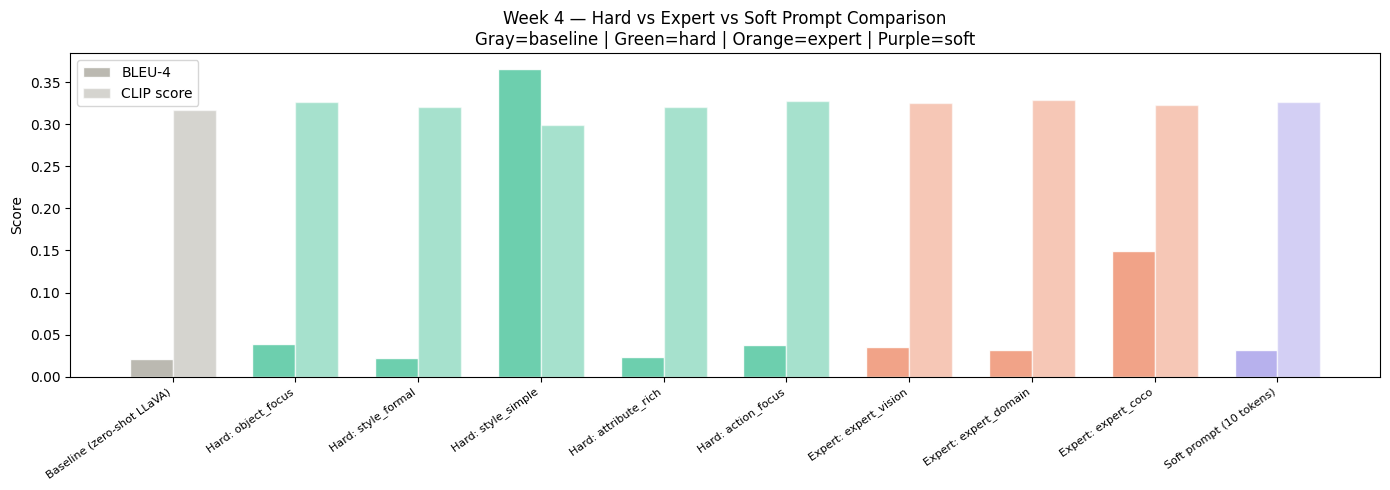

Comparison chart saved to /content/drive/MyDrive/dissertation_final/results/week4_prompt_comparison.png


In [18]:
# ── CELL 18 — Comparison chart ────────────────────────────────────────────
# Grouped bar chart: hard vs expert vs soft.
# Dissertation Figure 2.

df_plot = pd.DataFrame(all_results)

colors = []
for t in df_plot['technique']:
    if 'Baseline' in t or 'baseline' in t: colors.append('#B4B2A9')
    elif 'Expert' in t:                     colors.append('#F0997B')
    elif 'Soft' in t or 'soft' in t:        colors.append('#AFA9EC')
    else:                                   colors.append('#5DCAA5')

x = np.arange(len(df_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(max(12, len(df_plot)*1.4), 5))
ax.bar(x - w/2, df_plot['bleu_4'],          w, label='BLEU-4',    color=colors, alpha=0.9, edgecolor='white')
ax.bar(x + w/2, df_plot['clip_score_mean'], w, label='CLIP score', color=colors, alpha=0.55, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['technique'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title(
    'Week 4 — Hard vs Expert vs Soft Prompt Comparison\n'
    'Gray=baseline | Green=hard | Orange=expert | Purple=soft'
)
ax.legend()
plt.tight_layout()
out = f'{RESULTS_DIR}/week4_prompt_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Comparison chart saved to {out}')

In [19]:
# ── CELL 19 — Final verification ──────────────────────────────────────────
print('='*60)
print('Week 4 — Final verification')
print('='*60)

files = (
    [f'{RESULTS_DIR}/week4_hard_{n}.csv'   for n in HARD_PROMPT_VARIANTS] +
    [f'{RESULTS_DIR}/week4_expert_{n}.csv' for n in EXPERT_PROMPT_VARIANTS] +
    [f'{RESULTS_DIR}/week4_prompt_comparison.png',
     f'{RESULTS_DIR}/results_table.csv']
)
if soft_df is not None:
    files.append(f'{RESULTS_DIR}/week4_soft_prompt.csv')

all_ok = True
for fpath in files:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(fpath):45s} {size:>10,} bytes')
    if not exists: all_ok = False

print()
if all_ok:
    print('Week 4 complete.')
    print('Next: week5_embeddings_colab.ipynb')
else:
    print('Some files missing — re-run cells above.')

print()
print('Dissertation note:')
print('  Hard prompts   : Wang et al. (2023) heuristic baseline')
print('  Expert prompts : Xu et al. (2023) ExpertPrompting -- NEW')
print('  Soft prompts   : Wang et al. (2023) learnable approach')
print('  Novel finding  : First comparison of all three on LLaVA on COCO')

Week 4 — Final verification
  [OK] week4_hard_object_focus.csv                       80,866 bytes
  [OK] week4_hard_style_formal.csv                       83,146 bytes
  [OK] week4_hard_style_simple.csv                       44,907 bytes
  [OK] week4_hard_attribute_rich.csv                     82,556 bytes
  [OK] week4_hard_action_focus.csv                       84,915 bytes
  [OK] week4_expert_expert_vision.csv                    83,627 bytes
  [OK] week4_expert_expert_domain.csv                    82,728 bytes
  [OK] week4_expert_expert_coco.csv                      52,252 bytes
  [OK] week4_prompt_comparison.png                      102,617 bytes
  [OK] results_table.csv                                    593 bytes
  [OK] week4_soft_prompt.csv                             83,106 bytes

Week 4 complete.
Next: week5_embeddings_colab.ipynb

Dissertation note:
  Hard prompts   : Wang et al. (2023) heuristic baseline
  Expert prompts : Xu et al. (2023) ExpertPrompting -- NEW
  Soft prompt